<a href="https://colab.research.google.com/github/deltorobarba/astrophysics/blob/main/exoplanet_kepler10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Exoplanet Discovery for Kepler-10**

In [ ]:
# Lightkurve library installed, which is specifically designed to work with Kepler and TESS data.
!pip install lightkurve -q

[Kepler-10](https://en.m.wikipedia.org/wiki/Kepler-10), formerly known as KOI-72, is a Sun-like star in the constellation of Draco that lies 607 light-years (186 parsecs) from Earth. Kepler-10 was targeted by NASA's Kepler space telescope, as it was seen as the first star identified by the Kepler mission that could be a possible host to a small, transiting exoplanet.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Download light curve data for a specific target (Kepler ID or TIC ID)
# Example: Kepler-10 (a known star with a confirmed exoplanet)
target = 'Kepler-10'

# Search for light curve
lc_search = lk.search_lightcurve(target, mission="Kepler")
print(lc_search)

SearchResult containing 50 data products.

 #       mission      year   author   exptime         target_name          distance
                                         s                                  arcsec 
--- ----------------- ---- ---------- ------- ---------------------------- --------
  0 Kepler Quarter 02 2009     Kepler      60                kplr011904151      0.0
  1 Kepler Quarter 03 2009     Kepler      60                kplr011904151      0.0
  2 Kepler Quarter 03 2009     Kepler      60                kplr011904151      0.0
  3 Kepler Quarter 03 2009     Kepler      60                kplr011904151      0.0
  4 Kepler Quarter 00 2009     Kepler    1800                kplr011904151      0.0
  5 Kepler Quarter 01 2009     Kepler    1800                kplr011904151      0.0
  6 Kepler Quarter 02 2009     Kepler    1800                kplr011904151      0.0
  7 Kepler Quarter 03 2009     Kepler    1800                kplr011904151      0.0
  8 Kepler Quarter 07 2010     Ke

/usr/local/lib/python3.10/dist-packages/lightkurve/search.py:424: LightkurveWarning: Warning: 50 files available to download. Only the first file has been downloaded. Please use `download_all()` or specify additional criteria (e.g. quarter, campaign, or sector) to limit your search.
  warnings.warn(


<Axes: xlabel='Time - 2454833 [BKJD days]', ylabel='Flux [$\\mathrm{e^{-}\\,s^{-1}}$]'>

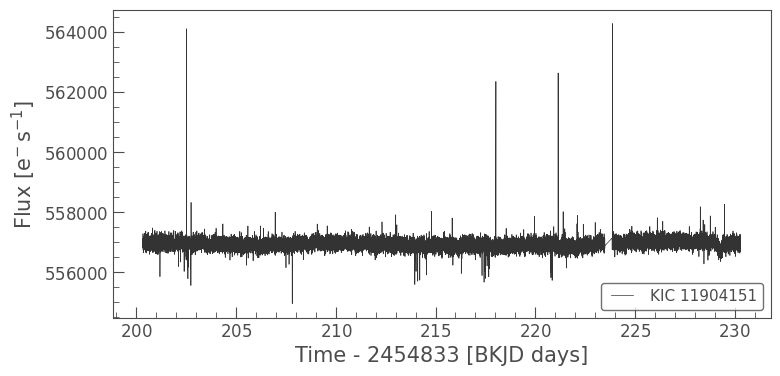

In [ ]:
# Download the data (just grabbing the first result here)
lc = lc_search.download(quality_bitmask="default")

# Plot the light curve
lc.plot(title=f"Light Curve for {target}")

<Axes: title={'center': 'Periodogram - Transit Detection'}, xlabel='Period [$\\mathrm{d}$]', ylabel='BLS Power'>

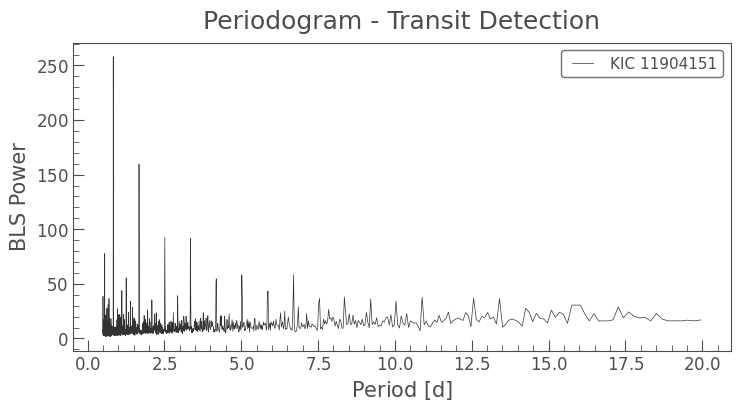

In [ ]:
# Clean the data by removing NaN values and flattening the curve
cleaned_lc = lc.remove_nans().flatten(window_length=401)

# Detect transits: Use a Box Least Squares (BLS) periodogram to find periodic dips in brightness, which could indicate planetary transits
periodogram = cleaned_lc.to_periodogram(method="bls", minimum_period=0.5, maximum_period=20)

# Plot the BLS periodogram to visualize detected periods (periodogram helps to visualize and extract the best-fit period, i.e. the time between transits
periodogram.plot(title="Periodogram - Transit Detection")

In [ ]:
# Get the best-fit transit period and duration
best_fit_period = periodogram.period_at_max_power
best_fit_duration = periodogram.duration_at_max_power
best_fit_depth = periodogram.depth_at_max_power

print(f"Best-fit period: {best_fit_period:.2f} days")
print(f"Best-fit transit duration: {best_fit_duration:.2f} days")
print(f"Transit depth: {best_fit_depth:.6f} relative flux")

Best-fit period: 0.84 d days
Best-fit transit duration: 0.05 d days
Transit depth: 0.000092 relative flux


Estimated planet radius: 0.01 solar radii


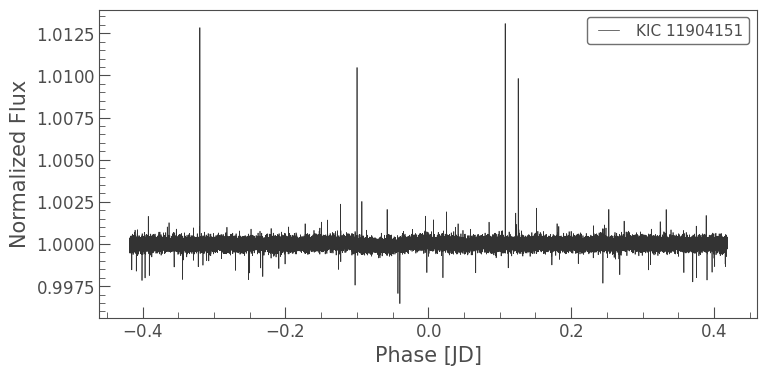

In [ ]:
# Fold the light curve by the detected period to see the repeated transits (By folding the light curve by detected period, observe repeated transits more clearly)
folded_lc = cleaned_lc.fold(period=best_fit_period.value)
folded_lc.plot(title=f"Folded Light Curve for {target} - Period: {best_fit_period:.2f} days")

# Estimate the planet radius using the transit depth (assuming the star's radius is known) -
# Using the depth of the transit and the star's radius, we estimate the planet's radius.
# Formula: (Rp/Rs)^2 = depth
# Rp = planet radius, Rs = star radius, depth = fractional dip in brightness
star_radius = 1.065  # Solar radii for Kepler-10
planet_radius = star_radius * np.sqrt(best_fit_depth)

print(f"Estimated planet radius: {planet_radius:.2f} solar radii")